# __EDA of Bike Details Dataset__

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Loadd the Dataset

df= pd.read_csv("BIKE DETAILS.csv")


In [3]:
# Check first 10 rows

df.head(10)


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0


In [4]:
# Check the shape of the DataFrame

df.shape


(1061, 7)

In [5]:
# Check the Data Types

df.dtypes


name                  object
selling_price          int64
year                   int64
seller_type           object
owner                 object
km_driven              int64
ex_showroom_price    float64
dtype: object

In [6]:
# Check 5 points summery

df.describe().T


,count,mean,std,min,25%,50%,75%,max
selling_price,1061.0,59638.151744,56304.291973,5000.0,28000.0,45000.0,70000.0,760000.0
year,1061.0,2013.867107,4.301191,1988.0,2011.0,2015.0,2017.0,2020.0
km_driven,1061.0,34359.833176,51623.152702,350.0,13500.0,25000.0,43000.0,880000.0
ex_showroom_price,626.0,87958.714058,77496.587189,30490.0,54852.0,72752.5,87031.5,1278000.0


In [7]:
# Check total numbers of Duplicates values

df.duplicated().sum()


np.int64(6)

In [8]:
# Drop the Duplicates

df = df.drop_duplicates()


In [9]:
# Again Check the shape of the DataFrame

df.shape


(1055, 7)

In [10]:
# Check total numbers of null values

df.isnull().sum()


name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    433
dtype: int64

In [11]:
# Check Unique Values of all features

#for i in df.columns:
#    x = df[i].unique()
#    print(f"{i}: {x}")
#    print()
    

### _Feature Engineering_

In [59]:
# Separation of Categorical and Numerical Features
# Categorical Features

cat_feature = [col for col in df.columns if df[col].dtypes == "object"]
cat_feature.remove('name')
cat_feature


['seller_type', 'owner']

In [13]:
# Numerical Fetures

num_feature = [col for col in df.columns if df[col].dtypes != "object"]
num_feature


['selling_price', 'year', 'km_driven', 'ex_showroom_price']

In [14]:
# Create a New Feature "bike_Age"
from datetime import datetime

current_age = datetime.now().year
df["bike_age"] = current_age - df["year"]


### *Univariate Analysis*

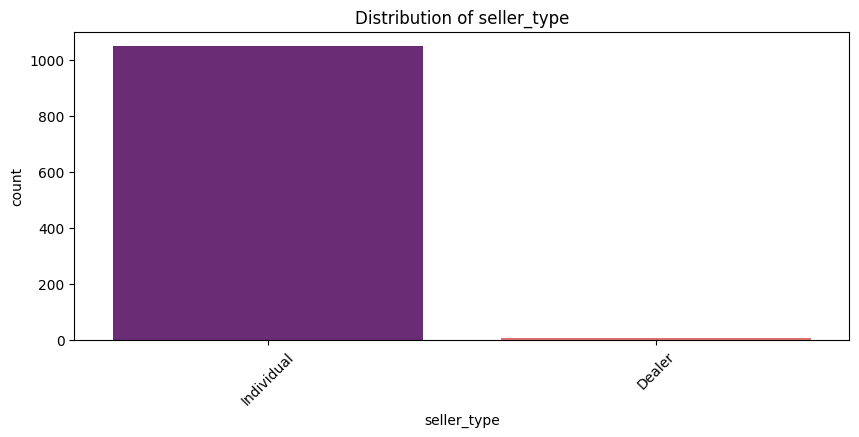

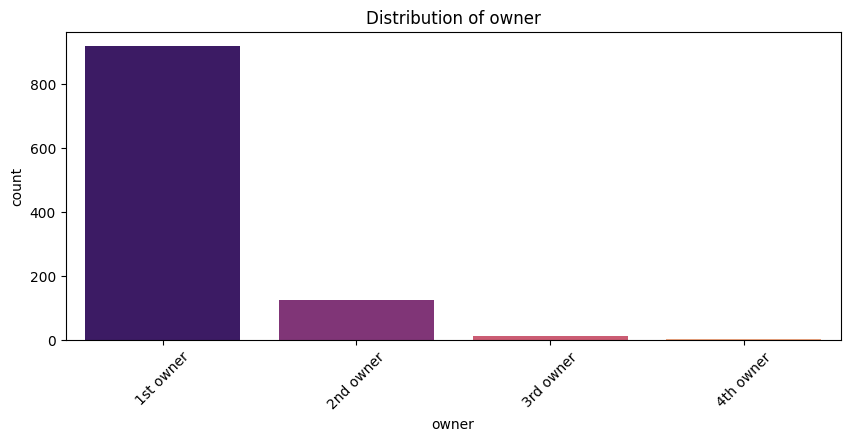

In [71]:
# Count Plot for Categorical Features

for col in cat_feature:
    plt.figure(figsize=[10,4])
    sns.countplot(data=df, x=col, palette="magma")
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.show()


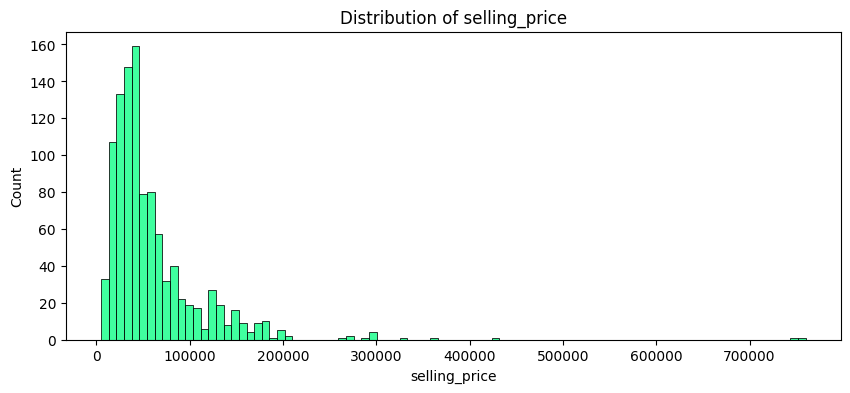

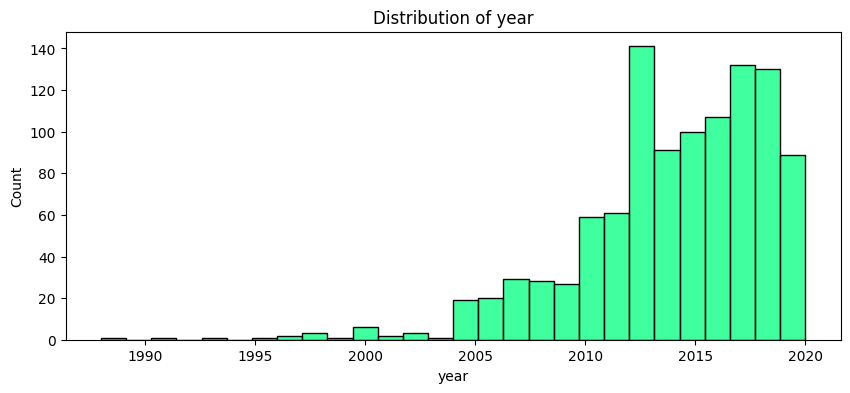

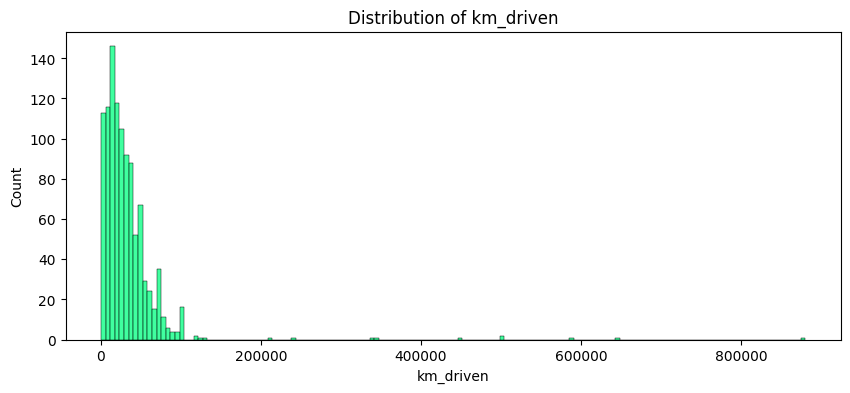

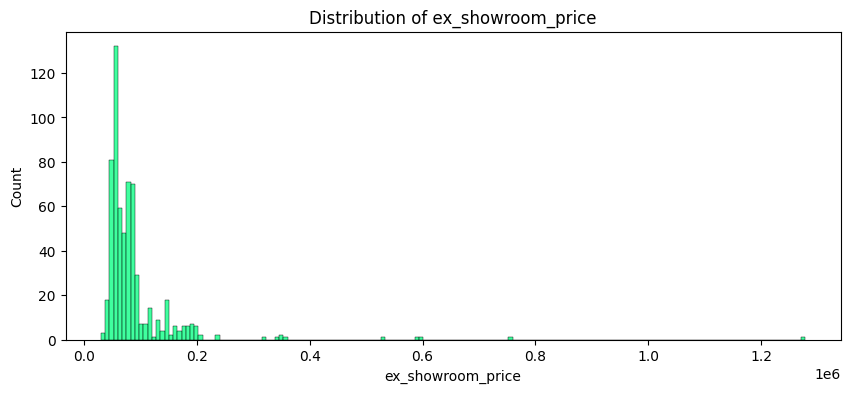

In [72]:
# Histogram for Numerical Features

for col in num_feature:
    plt.figure(figsize=[10,4])
    sns.histplot(df[col], color="springgreen")
    plt.title(f'Distribution of {col}')
    plt.show()


### *Bivariate Analysis*

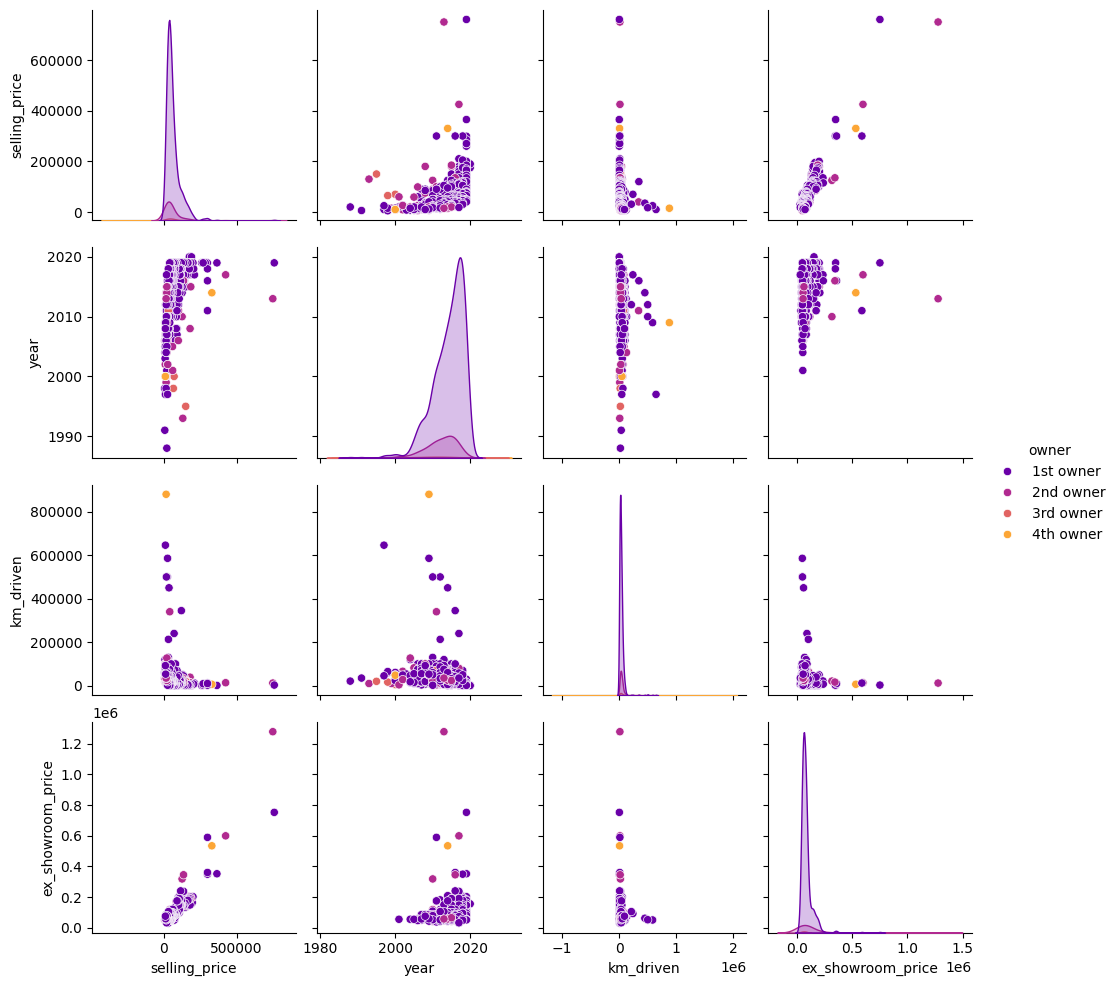

In [82]:
# Pair Plot

df_1 = df[['selling_price', "owner", 'year', 'km_driven', 'ex_showroom_price']]
sns.pairplot(df_1, hue="owner", palette="plasma").tight_layout()
plt.show()


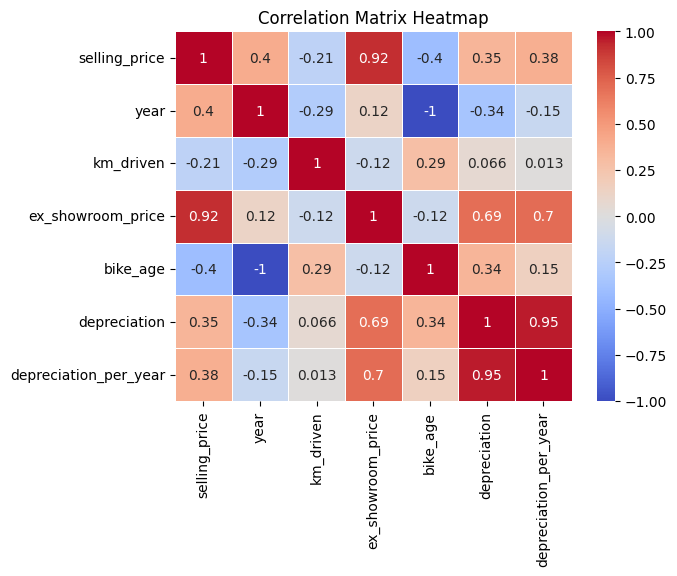

In [84]:
# Heatmap

corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

### Q1. What is the range of selling prices in the dataset?
Ans. 765000

In [15]:
min_sell_price = df["selling_price"].min()
max_sell_price = df["selling_price"].max()
sell_price_range = max_sell_price + min_sell_price
sell_price_range


np.int64(765000)

### Q2. What is the median selling price for bikes in the dataset?
Ans. 45000

In [16]:
df["selling_price"].median()


np.float64(45000.0)

### Q3. What is the most common seller type?
Ans. Individual

In [17]:
df["seller_type"].value_counts(normalize=True)*100


seller_type
Individual    99.43128
Dealer         0.56872
Name: proportion, dtype: float64

### Q4. How many bikes have driven more than 50,000 kilometers?
Ans. 168

In [18]:
len(df[df["km_driven"] > 50000])


168

### Q5. What is the average km_driven value for each ownership type?
Ans. 

In [19]:
round(df.groupby("owner")["km_driven"].mean(),2)


owner
1st owner     32732.71
2nd owner     39288.99
3rd owner     33292.18
4th owner    311500.00
Name: km_driven, dtype: float64

### Q6. What proportion of bikes are from the year 2015 or older?
Ans. 56.59%


In [20]:
df[df['year'] <= 2015].shape[0] 


597

In [21]:
proportion = df[df['year'] <= 2015].shape[0] / df.shape[0]
print(f"Proportion: {proportion:.2%}") # This prints it as a percentage


Proportion: 56.59%


### Q7. What is the trend of missing values across the dataset?

In [22]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df))*100

missing_df = pd.DataFrame({
    "Missing Values" : missing_values,
    "Missing Values in Percent" : missing_percentage.round(2)
})

missing_df


,Missing Values,Missing Values in Percent
name,0,0.00
selling_price,0,0.00
year,0,0.00
seller_type,0,0.00
owner,0,0.00
km_driven,0,0.00
ex_showroom_price,433,41.04
bike_age,0,0.00


### Q8. What is the highest ex_showroom_price recorded, and for which bike?


In [23]:
# 1st Method: using "loc" 
# Specify Row: ["ex_showroom_price"].idxmax(): only return the row where "ex_showroom_price" is highest
# Specify Column: ["name", "ex_showroom_price"]

df.loc[df["ex_showroom_price"].idxmax(), ["name", "ex_showroom_price"]]


name                 Harley-Davidson Street Bob
ex_showroom_price                     1278000.0
Name: 134, dtype: object

In [24]:
# 2nd Method: using Sort

df[["name", "ex_showroom_price"]].sort_values(by="ex_showroom_price", ascending=False).head(1)


,name,ex_showroom_price
134,Harley-Davidson Street Bob,1278000.0


### Q9. What is the total number of bikes listed by each seller type?


In [25]:
df["seller_type"].value_counts()


seller_type
Individual    1049
Dealer           6
Name: count, dtype: int64

### Q10. What is the relationship between selling_price and km_driven for first-owner bikes?


In [26]:
# Step 1: Filter out First-owner Bikes

first_owner_bikes = df[df["owner"] == '1st owner']


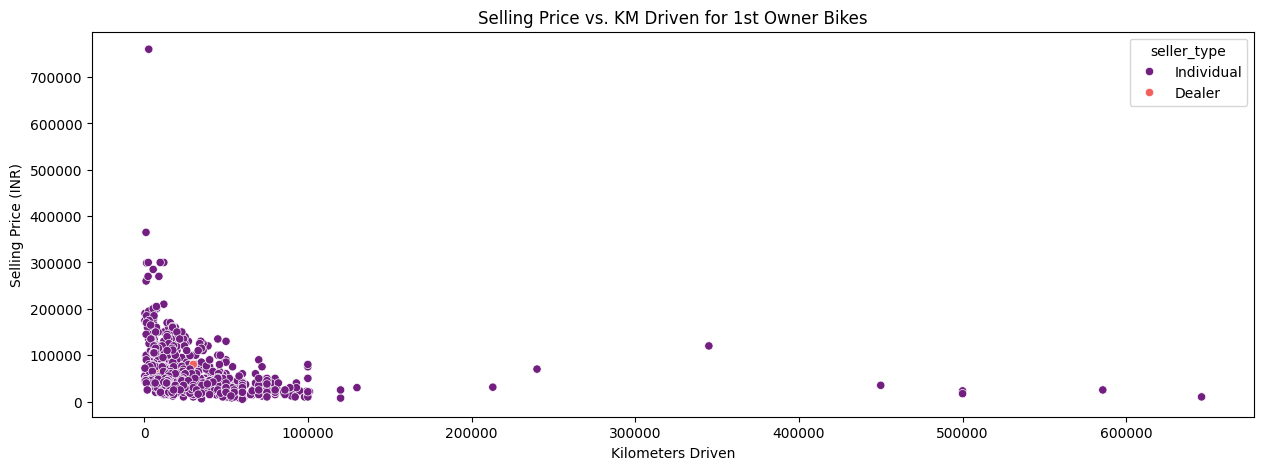

In [27]:
# Step 2: Scatter Plot b/w "selling_price" and "km_driven"

plt.figure(figsize=[15,5])
sns.scatterplot(data=first_owner_bikes, x="km_driven", y="selling_price", hue="seller_type", palette="magma")
plt.title('Selling Price vs. KM Driven for 1st Owner Bikes')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (INR)')
plt.show()


In [28]:
# Step 3: Correlation b/w "selling_price" and "km_driven"

correlation = first_owner_bikes['selling_price'].corr(first_owner_bikes['km_driven'])
print(f"Correlation: {correlation:.2f}")


Correlation: -0.24


__Negetive Relation__ between "selling_price" and "km_driven" for first-owner bikes


### Q11. Identify and remove outliers in the km_driven column using the IQR method.


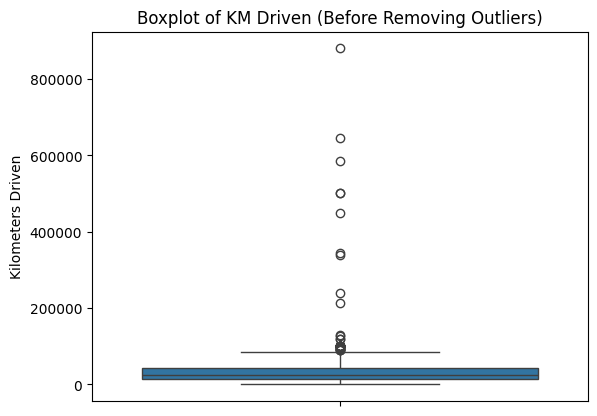

In [29]:
# Step 1: Box Plot to check the outliers

sns.boxplot(df['km_driven'])
plt.title('Boxplot of KM Driven (Before Removing Outliers)')
plt.ylabel('Kilometers Driven')
plt.show()


In [30]:
# IQR Method

Q1 = df["km_driven"].quantile(0.25)
Q3 = df["km_driven"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR


In [31]:
# Step 2: Apply IQR Method

df_filltered = df[(df['km_driven'] >= lower_fence) & (df['km_driven'] <= upper_fence)]


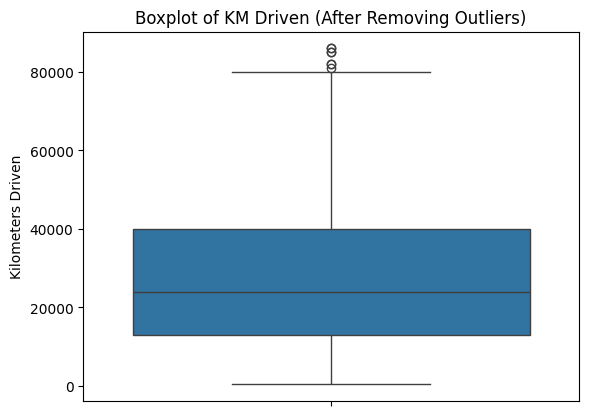

In [32]:
# Step 3: Again Box Plot to check the outliers

sns.boxplot(df_filltered['km_driven'])
plt.title('Boxplot of KM Driven (After Removing Outliers)')
plt.ylabel('Kilometers Driven')
plt.show()


### Q12. Perform a bivariate analysis to visualize the relationship between year and selling_price.


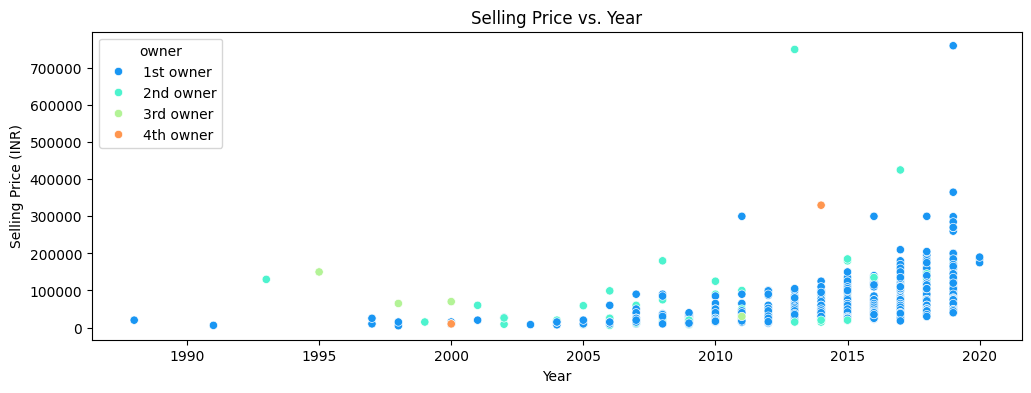

In [33]:
# Line Plot

plt.figure(figsize=[12,4])
sns.scatterplot(data=df, x="year", y="selling_price", hue="owner", palette="rainbow") 
plt.title('Selling Price vs. Year')
plt.xlabel('Year')
plt.ylabel('Selling Price (INR)')
plt.show()


__Strong Positive Relation__ b/w year and selling_price.

### Q13. What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)?

In [ ]:
# Step 1: Calculate depreciation amount
df['depreciation'] = df['ex_showroom_price'] - df['selling_price']

# Step 2: Calculate average depreciation per year
df['depreciation_per_year'] = df['depreciation'] / df['bike_age']

# Step 3: Get the average depreciation per year across all bikes
average_depreciation = df['depreciation_per_year'].mean()
print(f"Average depreciation per year: {average_depreciation:.2f}")


Average depreciation per year: 2667.84


__Note:__ We cant rely on the result that *Average depreciation per year: 2667.84*, cause in "ex_showroom_price" feature __41.04% values are missing__.

### Q14. Which bike names are priced significantly above the average price for their manufacturing year?


In [39]:
# Step 1: Calculate average selling price per year

# df.groupby('year') -> Groups the data by each manufacturing year.
# ['selling_price'].mean() -> Calculates the average selling price for each year.
# .reset_index() -> Converts the grouped data back to a DataFrame.
# .rename(...) -> Renames the column 'selling_price' to 'avg_price' for clarity.


year_avg = df.groupby('year')['selling_price'].mean().reset_index().rename(columns={'selling_price': 'avg_price'})
# year_avg


In [43]:
# Step 2: Merge back with original DataFrame
# Joins the original 'df' with 'year_avg' based on the 'year' column.

df_with_avg = df.merge(year_avg, on='year')
# df_with_avg


In [ ]:
# Step 3: Filter high-priced bikes
# Check Bike's 'selling price' greater than 1.5× the 'average price' for its year

high_priced_bikes = df_with_avg[df_with_avg['selling_price'] > 1.5 * df_with_avg['avg_price']]
# high_priced_bikes


In [52]:
# Step 4: Show the results

print(high_priced_bikes[['name', 'year', 'selling_price', 'avg_price']].reset_index(drop=True))


                                     name  year  selling_price      avg_price
0     Royal Enfield Classic Gunmetal Grey  2018         150000   87603.915385
1    Royal Enfield Bullet 350 [2007-2011]  2008         180000   34289.285714
2                           Yamaha YZF R3  2019         365000  119689.511628
3     Royal Enfield Classic Gunmetal Grey  2018         150000   87603.915385
4                           Jawa Standard  2019         180000  119689.511628
..                                    ...   ...            ...            ...
152             Royal Enfield Thunder 500  2015         105000   56500.000000
153             Royal Enfield Thunder 350  2013         105000   51152.777778
154             Royal Enfield Classic 350  2015         100000   56500.000000
155             Royal Enfield Classic 500  2014          95000   48668.131868
156             Royal Enfield Classic 500  2011          90000   35655.721311

[157 rows x 4 columns]


### Q15. Develop a correlation matrix for numeric columns and visualize it using a heatmap.


In [56]:
# Step 1: Correlation Matrix

corr_matrix = df.corr(numeric_only=True)
corr_matrix

,selling_price,year,km_driven,ex_showroom_price,bike_age,depreciation,depreciation_per_year
selling_price,1.000000,0.400947,-0.212005,0.918659,-0.400947,0.346646,0.383971
year,0.400947,1.000000,-0.287227,0.124832,-1.000000,-0.343829,-0.149986
km_driven,-0.212005,-0.287227,1.000000,-0.120752,0.287227,0.065957,0.012985
ex_showroom_price,0.918659,0.124832,-0.120752,1.000000,-0.124832,0.689006,0.698530
bike_age,-0.400947,-1.000000,0.287227,-0.124832,1.000000,0.343829,0.149986
depreciation,0.346646,-0.343829,0.065957,0.689006,0.343829,1.000000,0.954138
depreciation_per_year,0.383971,-0.149986,0.012985,0.698530,0.149986,0.954138,1.000000


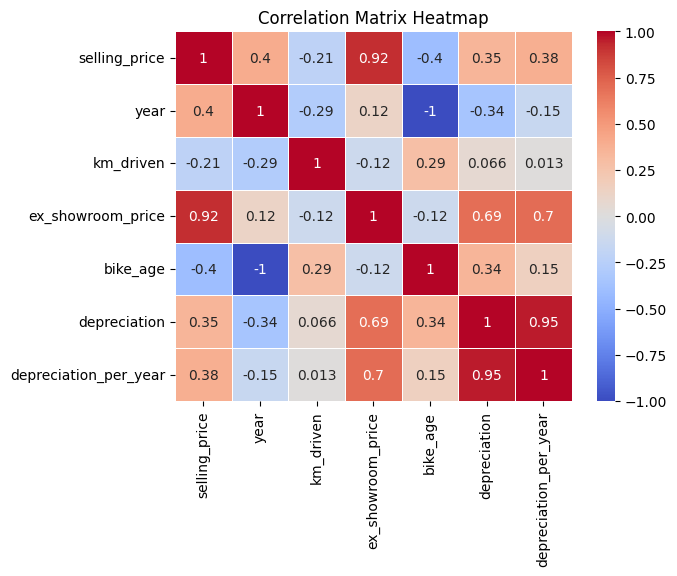

In [57]:
# Step 2: Heatmap

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()
